In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
from scipy.stats import pearsonr

In [29]:
def plot_expected_transfer(district, tol):
    # List of CSV files for each method

    if district == "all":
        csv_files = {
            'saturation': 'results/{}_equity_saturation_uncondtol={}.csv'.format(district, tol),
            'binary': 'results/{}_equity_binary_uncondtol={}.csv'.format(district, tol),
            'geographic': 'results/{}_equity_geographic_uncondtol={}.csv'.format(district,tol),
            'optimized': 'results/{}_equity_optimized_uncondtol={}.csv'.format(district, tol),
        }
        colors = cycle(['blue', 'orange', 'green', 'red'])
        fig, axs = plt.subplots(1, 4, figsize=(5*len(csv_files), 5), sharex=True, sharey=True)
    else:
        csv_files = {
            'saturation': 'results/{}_equity_saturation_uncondtol={}.csv'.format(district, tol),
            'binary': 'results/{}_equity_binary_uncondtol={}.csv'.format(district, tol),
            'optimized': 'results/{}_equity_optimized_uncondtol={}.csv'.format(district, tol),
        }
        colors = cycle(['blue', 'orange', 'red'])
        fig, axs = plt.subplots(1, 3, figsize=(5*len(csv_files), 5), sharex=True, sharey=True)

    for i, (method, csv_file) in enumerate(csv_files.items()):
        # Load data for the current method
        data = pd.read_csv(csv_file)

        # Plot consumption vs. average transfer value in the current subplot
        if district == "all":
            alpha = 0.02
        else:
            alpha = 0.3
        axs[i].scatter(np.log(data['consumption']), data['ev_transfer'], alpha=alpha, color=next(colors))
        axs[i].set_title(f'{method}')
        axs[i].set_xlabel('Log Consumption')
        axs[i].set_ylabel('Expected Transfer (2017 USD PPP) ')
        axs[i].grid(True)

    plt.suptitle(" Malawi District: {} \n Expected Transfer vs. Log Consumption \n Unconditional Tol={}".format(district, tol))
    plt.tight_layout()
    plt.savefig("figs/{}_equity_tol={}.pdf".format(district, tol))
    plt.show()

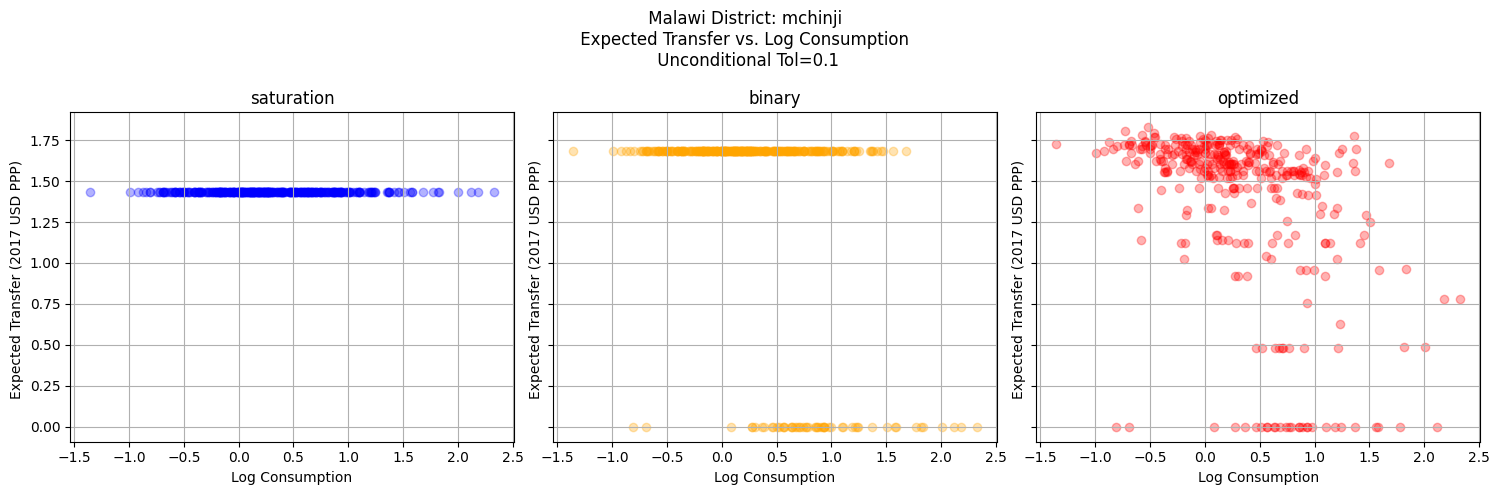

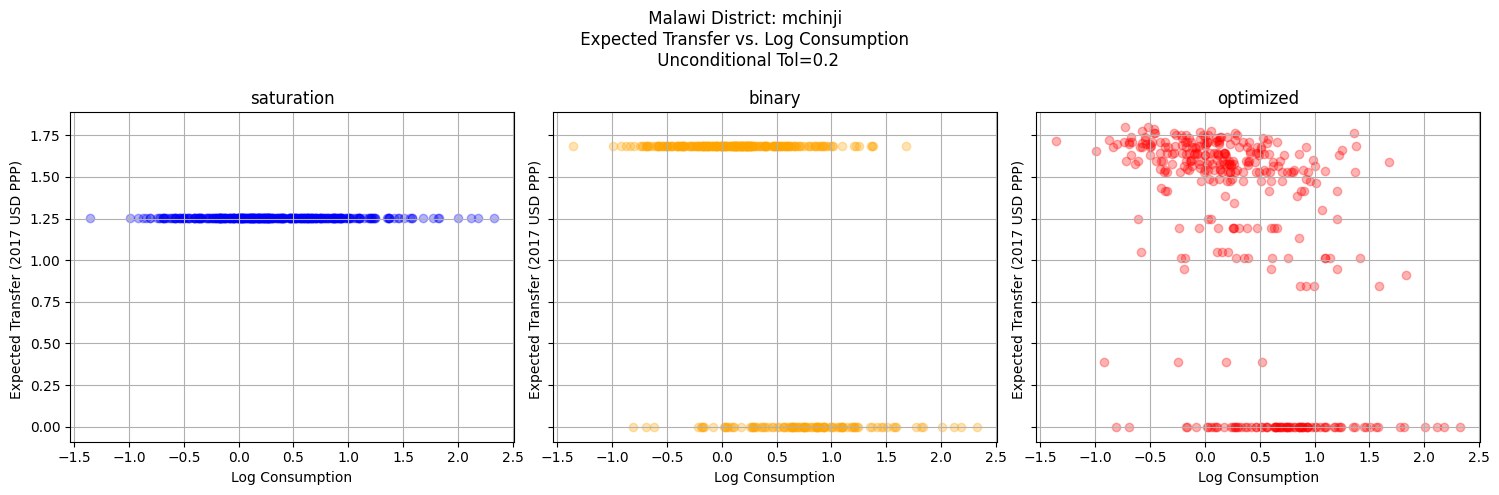

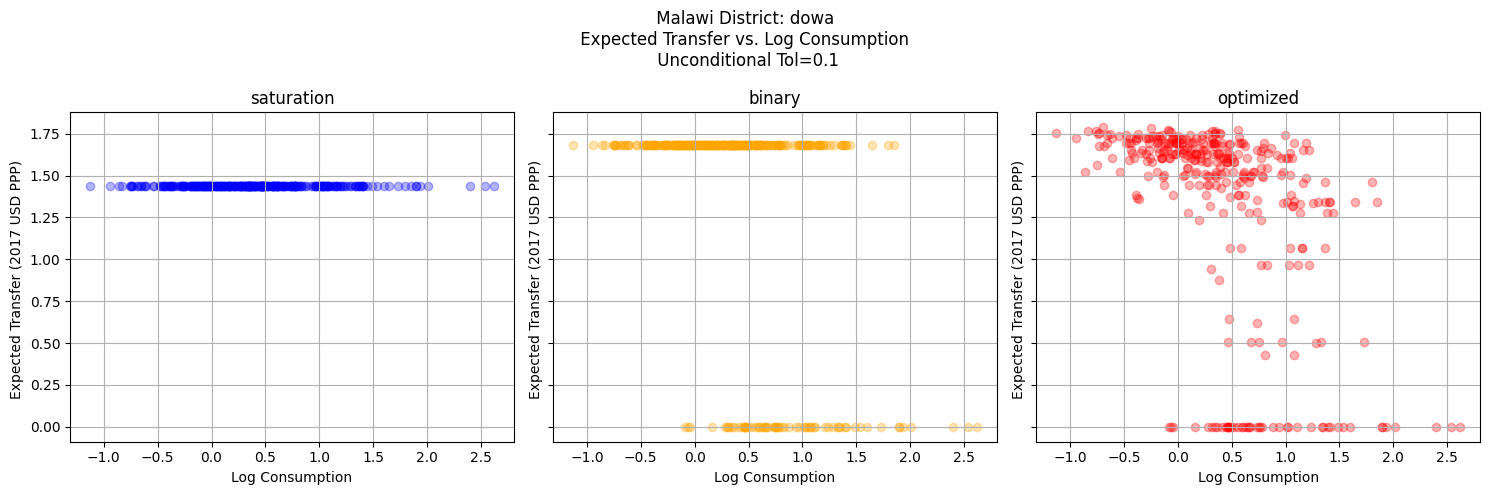

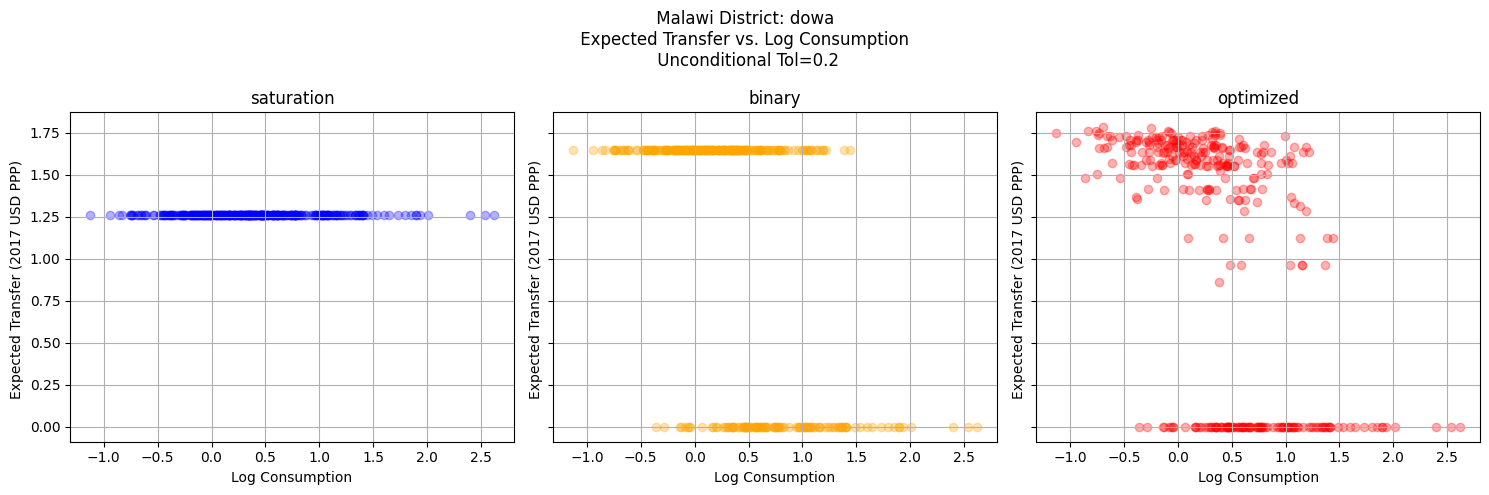

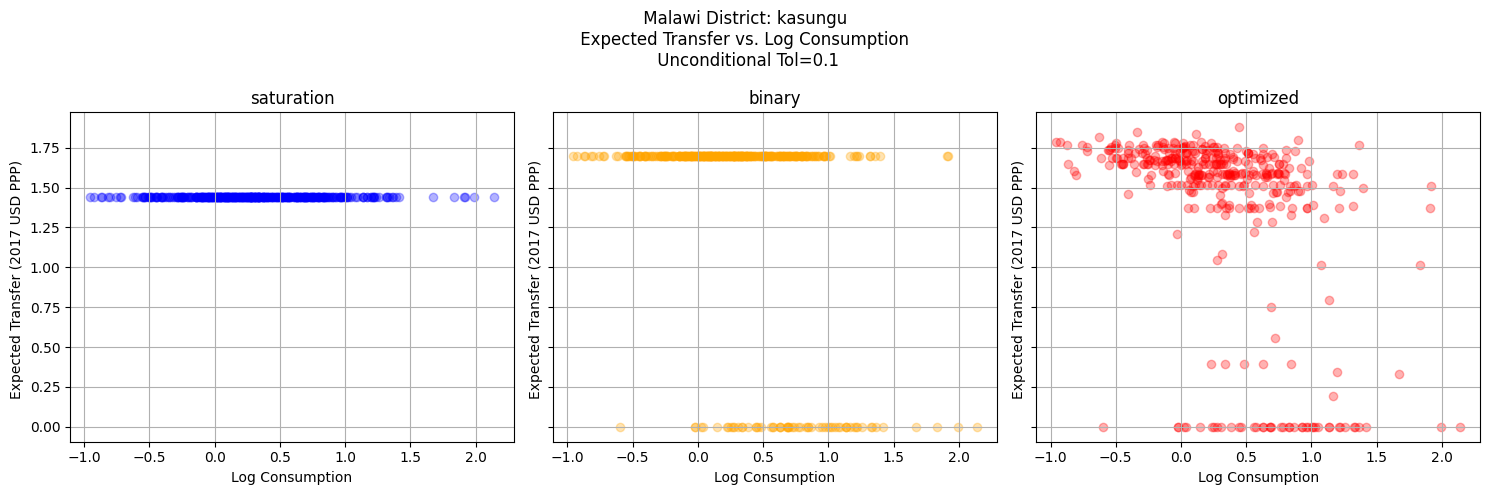

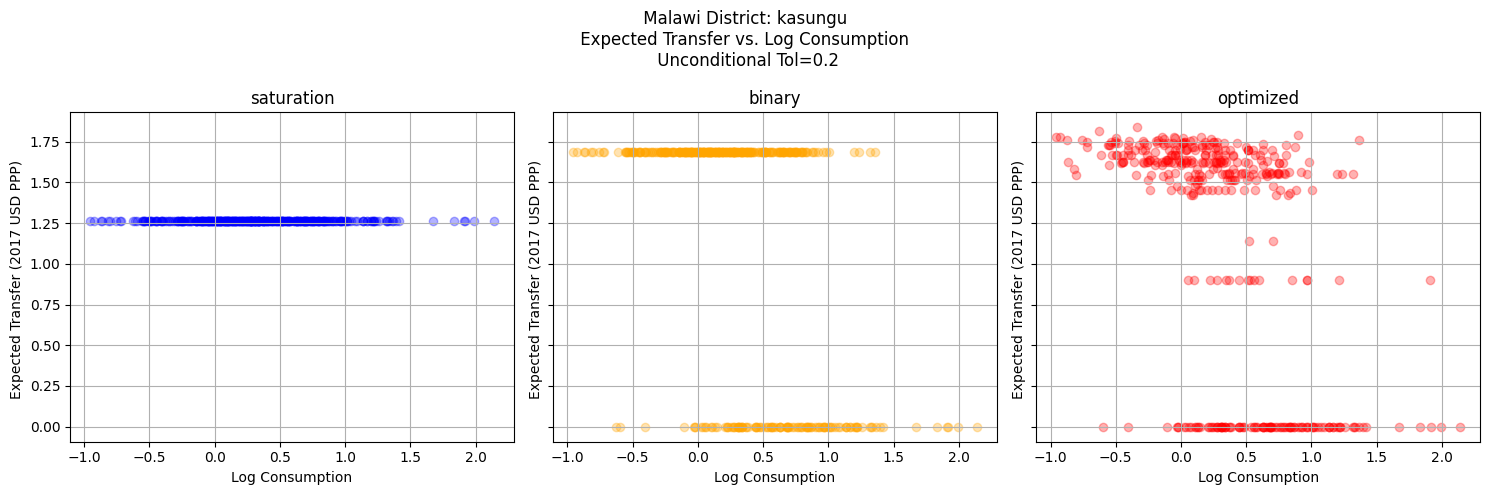

In [32]:
for district in ["mchinji", "dowa", "kasungu"]:
    for tol in [0.1, 0.2]:
        plot_expected_transfer(district, tol)